In [9]:
# dependencies
import pandas as pd
import numpy as np
import zipfile
import requests
import io
from sklearn.preprocessing import StandardScaler

import torch
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torch.nn as nn
import math


# Rishis notebook

In [10]:
def load_electricity_data():
  # Step 1: Download zip
  url = "https://archive.ics.uci.edu/static/public/321/electricityloaddiagrams20112014.zip"
  response = requests.get(url)

  # Step 2: Extract zip in memory
  z = zipfile.ZipFile(io.BytesIO(response.content))

  # Step 3: Read the txt file inside zip
  file_name = z.namelist()[0]   # should be LD2011_2014.txt

  df = pd.read_csv(
      z.open(file_name),
      sep=";",
      decimal=",",
      parse_dates=[0],
      quotechar='"'
  )

  # Step 4: Fix datetime column
  df.rename(columns={df.columns[0]: "datetime"}, inplace=True)
  df.set_index("datetime", inplace=True)
  return df

df = load_electricity_data()
df

,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
datetime,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2011-01-01 00:30:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2011-01-01 00:45:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2011-01-01 01:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2011-01-01 01:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-12-31 23:00:00,2.538071,22.048364,1.737619,150.406504,85.365854,303.571429,11.305822,282.828283,68.181818,72.043011,...,276.945039,28200.0,1616.033755,1363.636364,29.986962,5.851375,697.102722,176.961603,651.026393,7621.621622
2014-12-31 23:15:00,2.538071,21.337127,1.737619,166.666667,81.707317,324.404762,11.305822,252.525253,64.685315,72.043011,...,279.800143,28300.0,1569.620253,1340.909091,29.986962,9.947338,671.641791,168.614357,669.354839,6702.702703
2014-12-31 23:30:00,2.538071,20.625889,1.737619,162.601626,82.926829,318.452381,10.175240,242.424242,61.188811,74.193548,...,284.796574,27800.0,1556.962025,1318.181818,27.379400,9.362200,670.763828,153.589316,670.087977,6864.864865


In [11]:
def aggregate_data(df):
  df["total_load"] = df.sum(axis=1)
  df_hourly = df["total_load"].resample("H").sum().to_frame()
  df_hourly.head()
  return df_hourly

In [12]:
df_hourly = aggregate_data(df)

/tmp/ipykernel_560/4251397852.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df["total_load"].resample("H").sum().to_frame()


In [14]:
def create_features(df_hourly):
  # If df_hourly is a Series, convert it to a DataFrame first
  if isinstance(df_hourly, pd.Series):
      df_hourly = df_hourly.to_frame(name="total_load")

  # Make sure index is datetime
  df_hourly.index = pd.to_datetime(df_hourly.index)

  # Create a copy so original stays untouched
  df_features = df_hourly.copy()

  # Basic calendar/time features
  df_features["hour_of_day"] = df_features.index.hour
  df_features["day_of_week"] = df_features.index.dayofweek   # Monday=0, Sunday=6
  df_features["is_weekend"] = (df_features["day_of_week"] >= 5).astype(int)
  df_features["month"] = df_features.index.month

  # Optional cyclical encoding
  df_features["hour_sin"] = np.sin(2 * np.pi * df_features["hour_of_day"] / 24)
  df_features["hour_cos"] = np.cos(2 * np.pi * df_features["hour_of_day"] / 24)

  df_features["dayofweek_sin"] = np.sin(2 * np.pi * df_features["day_of_week"] / 7)
  df_features["dayofweek_cos"] = np.cos(2 * np.pi * df_features["day_of_week"] / 7)

  df_features["month_sin"] = np.sin(2 * np.pi * (df_features["month"] - 1) / 12)
  df_features["month_cos"] = np.cos(2 * np.pi * (df_features["month"] - 1) / 12)

  return df_features

In [15]:
df_features = create_features(df_hourly)
print(df_features.head())
print(df_features.columns)

                        total_load  hour_of_day  day_of_week  is_weekend  \
datetime                                                                   
2011-01-01 00:00:00  207058.270272            0            5           1   
2011-01-01 01:00:00  265378.510747            1            5           1   
2011-01-01 02:00:00  263924.219533            2            5           1   
2011-01-01 03:00:00  266306.134264            3            5           1   
2011-01-01 04:00:00  259854.210701            4            5           1   

                     month  hour_sin  hour_cos  dayofweek_sin  dayofweek_cos  \
datetime                                                                       
2011-01-01 00:00:00      1  0.000000  1.000000      -0.974928      -0.222521   
2011-01-01 01:00:00      1  0.258819  0.965926      -0.974928      -0.222521   
2011-01-01 02:00:00      1  0.500000  0.866025      -0.974928      -0.222521   
2011-01-01 03:00:00      1  0.707107  0.707107      -0.974928      

# normalizing df

In [16]:
def normalize_and_split(df_features, train_end='2013-12-31', val_start='2014-01-01',
                        val_end='2014-06-30', test_start='2014-07-01'):

    from sklearn.preprocessing import StandardScaler

    # Chronological split
    train = df_features[:train_end].copy()
    val = df_features[val_start:val_end].copy()
    test = df_features[test_start:].copy()

    # Scale total_load using only training data
    scaler = StandardScaler()
    scaler.fit(train[['total_load']])

    train['total_load_scaled'] = scaler.transform(train[['total_load']])
    val['total_load_scaled'] = scaler.transform(val[['total_load']])
    test['total_load_scaled'] = scaler.transform(test[['total_load']])

    # Print summary
    print(f"Train: {train.index.min()} to {train.index.max()} ({len(train)} rows)")
    print(f"Val:   {val.index.min()} to {val.index.max()} ({len(val)} rows)")
    print(f"Test:  {test.index.min()} to {test.index.max()} ({len(test)} rows)")

    return train, val, test, scaler

In [17]:
train, val, test, scaler = normalize_and_split(df_features)

Train: 2011-01-01 00:00:00 to 2013-12-31 23:00:00 (26304 rows)
Val:   2014-01-01 00:00:00 to 2014-06-30 23:00:00 (4344 rows)
Test:  2014-07-01 00:00:00 to 2015-01-01 00:00:00 (4417 rows)


create sequences

In [18]:
def create_sequences(data, input_window=168, forecast_horizon=24):
    feature_cols = ['total_load_scaled', 'hour_sin', 'hour_cos',
                    'dayofweek_sin', 'dayofweek_cos',
                    'month_sin', 'month_cos']

    features = data[feature_cols].values
    targets = data['total_load_scaled'].values

    X, y = [], []
    for i in range(len(features) - input_window - forecast_horizon + 1):
        X.append(features[i : i + input_window])
        y.append(targets[i + input_window : i + input_window + forecast_horizon])

    return torch.tensor(np.array(X), dtype=torch.float32), torch.tensor(np.array(y), dtype=torch.float32)

In [19]:
X_train, y_train = create_sequences(train)
X_val, y_val = create_sequences(val)
X_test, y_test = create_sequences(test)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape},   y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape},  y_test:  {y_test.shape}")

X_train: torch.Size([26113, 168, 7]), y_train: torch.Size([26113, 24])
X_val:   torch.Size([4153, 168, 7]),   y_val:   torch.Size([4153, 24])
X_test:  torch.Size([4226, 168, 7]),  y_test:  torch.Size([4226, 24])


Data loader ( batching)

In [20]:


def create_dataloaders(X_train, y_train, X_val, y_val, X_test, y_test, batch_size=64):
    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

    # Sanity check
    x_batch, y_batch = next(iter(train_loader))
    print(f"Input batch shape:  {x_batch.shape}")
    print(f"Target batch shape: {y_batch.shape}")

    return train_loader, val_loader, test_loader



In [21]:
train_loader, val_loader, test_loader = create_dataloaders(X_train, y_train, X_val, y_val, X_test, y_test)

Input batch shape:  torch.Size([64, 168, 7])
Target batch shape: torch.Size([64, 24])


persistence baseline( for comparision)

In [22]:
def persistence_baseline(X_test, y_test, scaler):
    # Grab the last 24 hours of total_load_scaled from each input window
    # total_load_scaled is the first column (index 0) in our features
    predictions = X_test[:, -24:, 0]  # last 24 timesteps, load column only
    actuals = y_test

    # Convert back to original scale for interpretable metrics
    pred_original = scaler.inverse_transform(predictions.reshape(-1, 1)).reshape(predictions.shape)
    actual_original = scaler.inverse_transform(actuals.reshape(-1, 1)).reshape(actuals.shape)

    mae = np.mean(np.abs(actual_original - pred_original))
    rmse = np.sqrt(np.mean((actual_original - pred_original) ** 2))
    mape = np.mean(np.abs((actual_original - pred_original) / actual_original)) * 100

    print(f"Persistence Baseline:")
    print(f"  MAE:  {mae:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MAPE: {mape:.2f}%")

    return mae, rmse, mape



In [23]:
baseline_mae, baseline_rmse, baseline_mape = persistence_baseline(X_test, y_test, scaler)

Persistence Baseline:
  MAE:  35421.18
  RMSE: 59571.34
  MAPE: 3.87%


# Transformer

In [24]:


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # shape: [1, max_len, d_model]

        self.register_buffer('pe', pe)

    def forward(self, x):
        # x shape: [batch, seq_len, d_model]
        x = x + self.pe[:, :x.size(1), :]
        return x

In [25]:
# DELETE or skip any previous cell that defines ElectricityTransformer

class ElectricityTransformer(nn.Module):
    def __init__(self, input_features=7, d_model=64, nhead=4, num_layers=2,
                 dim_feedforward=128, dropout=0.1, input_window=168,
                 forecast_horizon=24, num_quantiles=3):
        super().__init__()
        self.forecast_horizon = forecast_horizon
        self.num_quantiles = num_quantiles

        self.input_projection = nn.Linear(input_features, d_model)
        self.positional_encoding = PositionalEncoding(d_model, max_len=input_window)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.output_head = nn.Sequential(
            nn.Linear(d_model * input_window, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, forecast_horizon * num_quantiles)
        )

    def forward(self, x):
        x = self.input_projection(x)
        x = self.positional_encoding(x)
        x = self.transformer_encoder(x)
        x = x.reshape(x.size(0), -1)
        x = self.output_head(x)
        x = x.reshape(-1, self.forecast_horizon, self.num_quantiles)
        return x



In [26]:
# Immediate test right here in the same cell
model = ElectricityTransformer()
test_output = model(torch.randn(2, 168, 7))
print(f"Output shape: {test_output.shape}")

Output shape: torch.Size([2, 24, 3])


In [27]:
class QuantileLoss(nn.Module):
    def __init__(self, quantiles=[0.1, 0.5, 0.9]):
        super().__init__()
        self.quantiles = quantiles

    def forward(self, predictions, targets):
        # predictions shape: [batch, 24, num_quantiles]
        # targets shape: [batch, 24]

        targets = targets.unsqueeze(-1)  # [batch, 24, 1] for broadcasting
        losses = []

        for i, q in enumerate(self.quantiles):
            errors = targets - predictions[:, :, i].unsqueeze(-1)
            loss = torch.max(q * errors, (q - 1) * errors)
            losses.append(loss.mean())

        return sum(losses) / len(losses)

In [28]:
def train_model(model, train_loader, val_loader, criterion, num_epochs=30, lr=1e-3, device='cpu'):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

    train_losses = []
    val_losses = []
    best_val_loss = float('inf')

    for epoch in range(num_epochs):
        # --- Training ---
        model.train()
        epoch_train_loss = 0
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            predictions = model(x_batch)
            loss = criterion(predictions, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_train_loss += loss.item()

        avg_train_loss = epoch_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # --- Validation ---
        model.eval()
        epoch_val_loss = 0
        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                predictions = model(x_batch)
                loss = criterion(predictions, y_batch)
                epoch_val_loss += loss.item()

        avg_val_loss = epoch_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        # Update learning rate based on val loss
        scheduler.step(avg_val_loss)

        # Save best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), 'best_model.pt')

        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | LR: {current_lr:.6f}")

    # Load best model
    model.load_state_dict(torch.load('best_model.pt'))
    print(f"\nTraining complete. Best Val Loss: {best_val_loss:.4f}")

    return model, train_losses, val_losses

In [29]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = ElectricityTransformer().to(device)
criterion = QuantileLoss(quantiles=[0.1, 0.5, 0.9])

model, train_losses, val_losses = train_model(model, train_loader, val_loader, criterion, num_epochs=30, device=device)

Using device: cuda
Epoch 1/30 | Train Loss: 0.0809 | Val Loss: 0.0420 | LR: 0.001000
Epoch 2/30 | Train Loss: 0.0512 | Val Loss: 0.0424 | LR: 0.001000
Epoch 3/30 | Train Loss: 0.0467 | Val Loss: 0.0443 | LR: 0.001000
Epoch 4/30 | Train Loss: 0.0457 | Val Loss: 0.0329 | LR: 0.001000
Epoch 5/30 | Train Loss: 0.0445 | Val Loss: 0.0446 | LR: 0.001000
Epoch 6/30 | Train Loss: 0.0445 | Val Loss: 0.0307 | LR: 0.001000
Epoch 7/30 | Train Loss: 0.0429 | Val Loss: 0.0341 | LR: 0.001000
Epoch 8/30 | Train Loss: 0.0421 | Val Loss: 0.0387 | LR: 0.001000
Epoch 9/30 | Train Loss: 0.0422 | Val Loss: 0.0402 | LR: 0.001000
Epoch 10/30 | Train Loss: 0.0416 | Val Loss: 0.0288 | LR: 0.001000
Epoch 11/30 | Train Loss: 0.0408 | Val Loss: 0.0325 | LR: 0.001000
Epoch 12/30 | Train Loss: 0.0402 | Val Loss: 0.0363 | LR: 0.001000
Epoch 13/30 | Train Loss: 0.0401 | Val Loss: 0.0266 | LR: 0.001000
Epoch 14/30 | Train Loss: 0.0396 | Val Loss: 0.0261 | LR: 0.001000
Epoch 15/30 | Train Loss: 0.0394 | Val Loss: 0.0310 

In [30]:
def evaluate_model(model, test_loader, scaler, device='cpu'):
    model.eval()
    all_predictions = []
    all_actuals = []

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            predictions = model(x_batch)  # [batch, 24, 3]
            all_predictions.append(predictions.cpu().numpy())
            all_actuals.append(y_batch.numpy())

    all_predictions = np.concatenate(all_predictions, axis=0)  # [num_samples, 24, 3]
    all_actuals = np.concatenate(all_actuals, axis=0)          # [num_samples, 24]

    # Extract quantiles (still in scaled space)
    q10_scaled = all_predictions[:, :, 0]
    q50_scaled = all_predictions[:, :, 1]  # median = point forecast
    q90_scaled = all_predictions[:, :, 2]

    # Inverse transform to original scale
    q10 = scaler.inverse_transform(q10_scaled.reshape(-1, 1)).reshape(q10_scaled.shape)
    q50 = scaler.inverse_transform(q50_scaled.reshape(-1, 1)).reshape(q50_scaled.shape)
    q90 = scaler.inverse_transform(q90_scaled.reshape(-1, 1)).reshape(q90_scaled.shape)
    actuals = scaler.inverse_transform(all_actuals.reshape(-1, 1)).reshape(all_actuals.shape)

    # Point forecast metrics (using median / q50)
    mae = np.mean(np.abs(actuals - q50))
    rmse = np.sqrt(np.mean((actuals - q50) ** 2))
    mape = np.mean(np.abs((actuals - q50) / actuals)) * 100

    # Probabilistic metric: PICP (Prediction Interval Coverage Probability)
    # What % of actual values fall within the 10th-90th percentile interval
    in_interval = ((actuals >= q10) & (actuals <= q90)).mean() * 100

    print(f"Transformer Results (Test Set):")
    print(f"  MAE:  {mae:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MAPE: {mape:.2f}%")
    print(f"  PICP (10-90): {in_interval:.2f}% (target: ~80%)")
    print(f"\nBaseline Comparison:")
    print(f"  Baseline MAE:  35421.18")
    print(f"  Baseline RMSE: 59571.34")
    print(f"  Baseline MAPE: 3.87%")

    return actuals, q10, q50, q90

actuals, q10, q50, q90 = evaluate_model(model, test_loader, scaler, device=device)

Transformer Results (Test Set):
  MAE:  30538.59
  RMSE: 44976.27
  MAPE: 3.30%
  PICP (10-90): 92.52% (target: ~80%)

Baseline Comparison:
  Baseline MAE:  35421.18
  Baseline RMSE: 59571.34
  Baseline MAPE: 3.87%


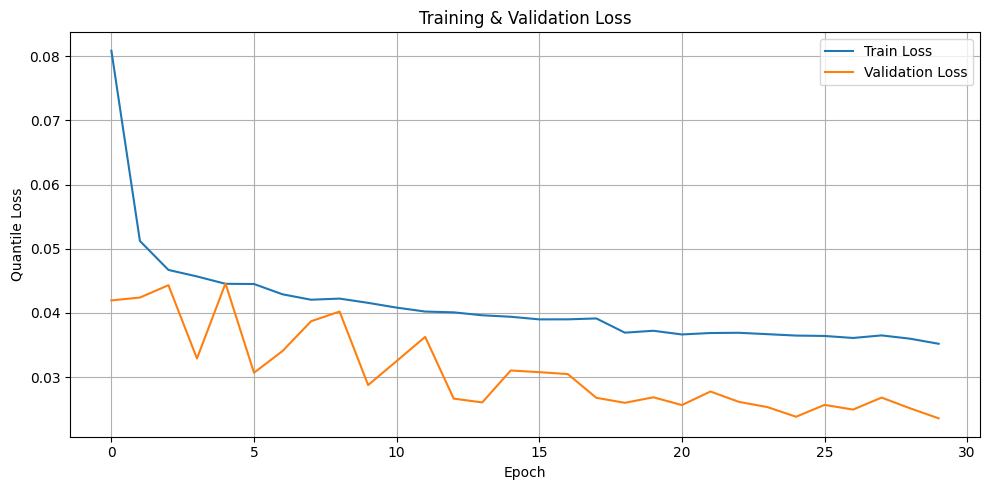

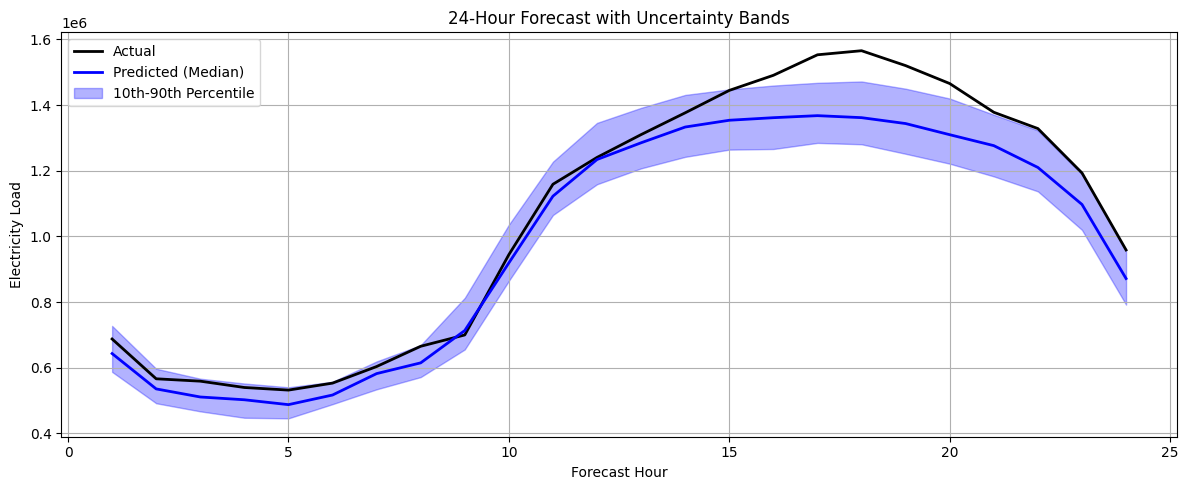

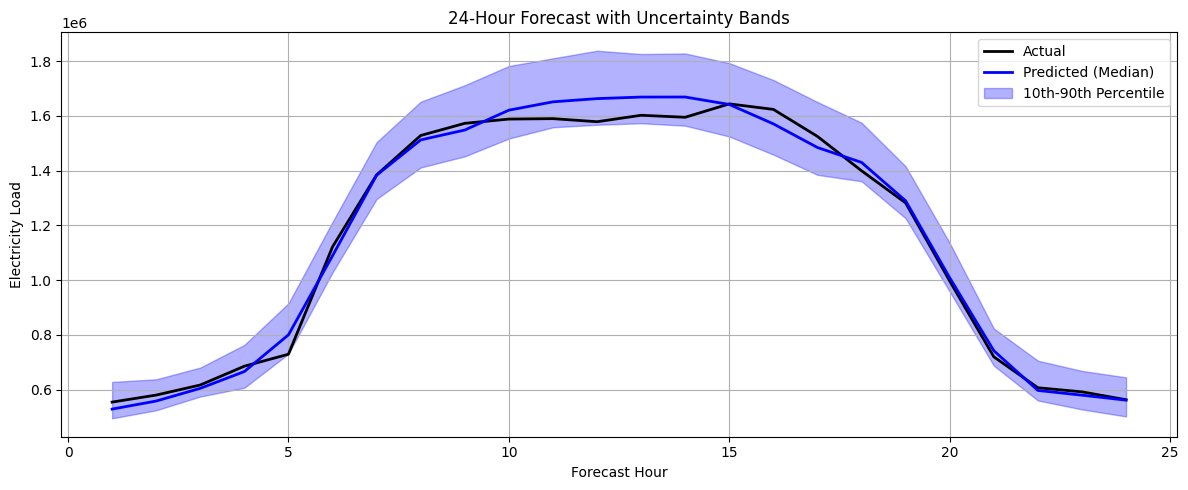

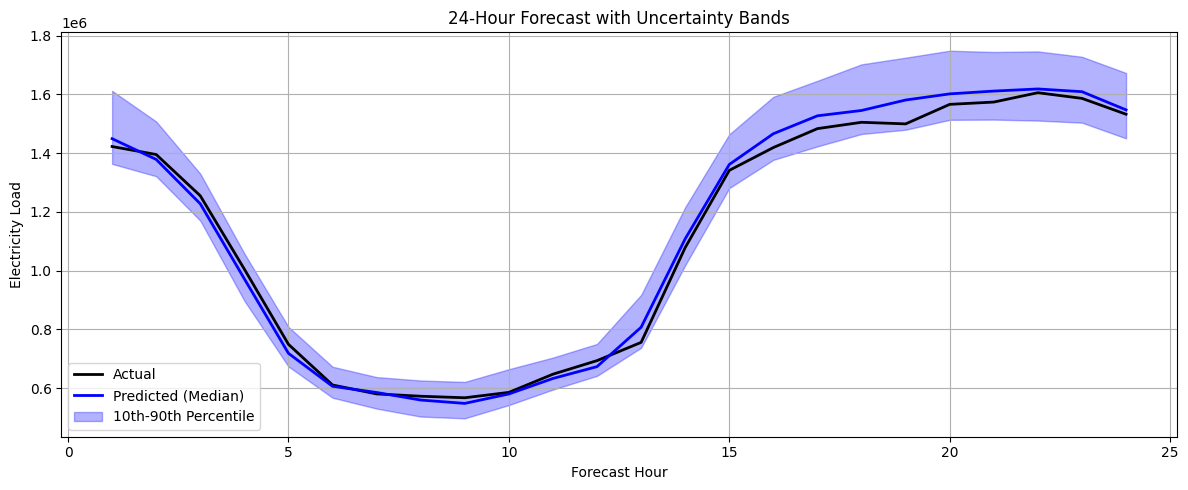

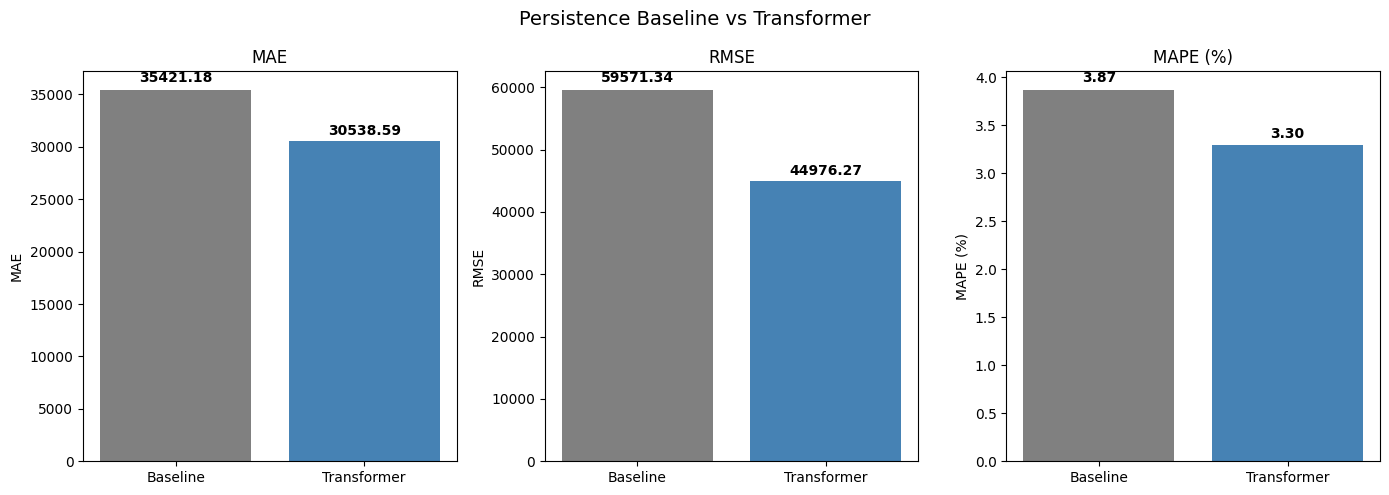

In [31]:
import matplotlib.pyplot as plt

# --- Plot 1: Training & Validation Loss Curves ---
def plot_loss_curves(train_losses, val_losses):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Quantile Loss')
    plt.title('Training & Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_loss_curves(train_losses, val_losses)


# --- Plot 2: 24-Hour Forecast with Uncertainty Bands ---
def plot_forecast_with_bands(actuals, q10, q50, q90, sample_idx=0):
    hours = np.arange(1, 25)

    plt.figure(figsize=(12, 5))
    plt.plot(hours, actuals[sample_idx], label='Actual', color='black', linewidth=2)
    plt.plot(hours, q50[sample_idx], label='Predicted (Median)', color='blue', linewidth=2)
    plt.fill_between(hours, q10[sample_idx], q90[sample_idx], alpha=0.3, color='blue', label='10th-90th Percentile')
    plt.xlabel('Forecast Hour')
    plt.ylabel('Electricity Load')
    plt.title('24-Hour Forecast with Uncertainty Bands')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Plot a few different samples
plot_forecast_with_bands(actuals, q10, q50, q90, sample_idx=0)
plot_forecast_with_bands(actuals, q10, q50, q90, sample_idx=100)
plot_forecast_with_bands(actuals, q10, q50, q90, sample_idx=500)


# --- Plot 3: Baseline vs Transformer Comparison Bar Chart ---
def plot_comparison():
    metrics = ['MAE', 'RMSE', 'MAPE (%)']
    baseline_vals = [35421.18, 59571.34, 3.87]
    transformer_vals = [30538.59, 44976.27, 3.30]

    fig, axes = plt.subplots(1, 3, figsize=(14, 5))

    for i, (metric, base, trans) in enumerate(zip(metrics, baseline_vals, transformer_vals)):
        axes[i].bar(['Baseline', 'Transformer'], [base, trans], color=['gray', 'steelblue'])
        axes[i].set_title(metric)
        axes[i].set_ylabel(metric)

        # Add value labels on bars
        axes[i].text(0, base + base * 0.02, f'{base:.2f}', ha='center', fontweight='bold')
        axes[i].text(1, trans + trans * 0.02, f'{trans:.2f}', ha='center', fontweight='bold')

    plt.suptitle('Persistence Baseline vs Transformer', fontsize=14)
    plt.tight_layout()
    plt.show()

plot_comparison()